# Sample mean simulation example

This notebook expands upon our coverage of the statistical properties of the sample mean. 

Just like the question I asked on the incoming survey, we will assume i.i.d. (independent and identically distributed data) from a Normal distribution with mean 5 (although this can be changed) and a standard deviation of 10 (also can be changed), and a sample size of 100 (again, this can be changed). 

## Key results from class

First, in order to derive the key results, we used the following key properties of means and variances:

1. $E(aX + Y) = aE(X) + E(Y)$ where $a$ is any constant and $X$ and $Y$ are random variables (they don't need to be independent!).

2. If $X$ and $Y$ are *independent* random variables (technically, all we really need is that they are uncorrelated), then:
$\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y)$.

3.  $\text{Var}(aX) = a^{2}\text{Var}(X)$ where again a is any constant.

With $\bar{X} = (1/N)\sum_{n=1}^{N} X_{n}$ equal to the sample mean, we showed that:

$E(\bar{X}) = \mu$ where $\mu = E(X)$ is the true (population) mean. (In our specific example, this is 5.)

$\text{Var} (\bar{X}) = \frac{\sigma^{2}}{N}$ and thus $\text{Std. Dev.}(\bar{X}) = \frac{\sigma}{\sqrt{N}}$. In our example, N = 100 and $\sigma = 10$, so  $\text{Std. Dev.}(\bar{X}) = 1$.

The Python code below illustrates these results using a simulation setup, which is very useful in data science.

In [5]:
#We will need some Python modules
import numpy as np
import pandas as pd

#Let's set the key parameters

#true mean
xmu = 5
#true std
xstd = 10

#sample size (can be changed of course)
N = 100

print(N)

100


## One sample
Next, we will do generate *one* sample of data and compute the mean. We will see that the sample mean does not correspond to the true mean, due to the effects of sampling error.

Python code:

In [8]:
#Do one simulation to illustrate
rng = np.random.RandomState(10)  # deterministic random data
sim_x = np.random.normal(loc=xmu, scale=xstd, size=N)

print("Here is our first simulated set of data: ", sim_x)

#Now compute the sample mean

smean = np.mean(sim_x)
print("Here is the sample mean for this particular sample", smean)
print("It does not equal the true value (5)! This is not surprising and is due to sampling error")





Here is our first simulated set of data:  [  4.60423323 -13.0729433    4.27373423   6.1014355  -10.99606703
  13.67087701  -4.01203125   2.43631183   6.64216662 -11.13321188
  18.83937915 -10.62086175   8.29585394  13.0391231   -8.19776267
  11.58339051  -6.34416697   7.6899568    7.12691735  -5.93603297
  -5.51141295  23.38727751   8.89030012   4.30900161   9.1985665
   8.30228003   4.16360643  11.22615109 -25.83009928  -3.8597838
 -11.44951912   5.98612815  16.15608445   6.32516088  12.99454762
  12.91881562  -9.25409695   4.14361869  12.33014362  16.25416203
  -0.6085731    7.35630856  -0.60724163  -4.10070179   3.59167746
   6.70063796  27.3506815    4.01784738  -1.12060152  -2.3168967
  15.55608653   1.38694424  21.85458385  15.94969008 -14.06197956
  19.87854009   7.44277275  -6.11085045  -1.18665212   3.36571146
   9.74873005  -3.21536217  10.25058895   3.95925601   2.28038722
  -4.88202828  16.769674    15.00254522  12.4730241   16.83753684
  14.42848712  15.03329633   7.421403

## More simluations

In order to see what the distribution of the sample mean looks like, we will now to a *lot* of simluations similar to the above. This will give us many realizations of the sample mean, and we can then confirm (up to a tiny bit of simulation error) the results we derived analytically in class. 

In [11]:
#number of simulations (we generally want this to be 'large' so that we get the approximate properites of the estimator)
B = 5000

#Initialize a holder for our sample means
sim_outcomes = []
#Now we will do a loop in python:

for i in np.arange(0,B):
    #simulate new data
    sim_x = np.random.normal(loc=xmu, scale=xstd, size=N)
    #compute the mean
    smean = np.mean(sim_x)
    #keep the mean we computed
    sim_outcomes.append(smean)

#make a Pandas DataFrame (for convenience)
sim_df = pd.DataFrame(sim_outcomes)  
sim_df.head(20)
    

,0
0,4.989410
1,5.660660
2,5.336246
3,4.142713
4,4.155366
5,4.183093
6,4.947145
7,6.108072
8,3.403753
9,4.629996


In [13]:
#report descriptive statistics for the sample means
sim_df.describe()



,0
count,5000.000000
mean,5.021111
std,1.007295
min,0.953051
25%,4.349910
50%,5.020943
75%,5.689617
max,8.441689


## Interpretation of the simulation results

The theoretical result is that $E(\bar{X})=\mu$, i.e., the average realized of the sample mean should be the population mean in our setting. Since the population mean equals 5, the mean of the simulated sample means should be equal to five. The simulation mean is extremely close to 5, and the difference could be made even smaller by increasing the simulation size.

Our other theoretical result is that $\text{Std. Dev.}(\bar{X}) = \frac{\sigma}{\sqrt{N}}$, which given our paraetmers (N = 100, $\sigma = 10$), should be one. The standard deviation of the simulated means is extremely close to one, just as we expect.

We also expect the sample mean to follow a normal distribution. *Note: This follows from the probability result that the sum of normally distributed random variables also follows a normal distribution, as does the produce of a constant (such as 1/N) and a normally distributed variable.*

To see that this holds in the data, we plot a histogram of the simulated sample means. 

array([[<Axes: title={'center': '0'}>]], dtype=object)

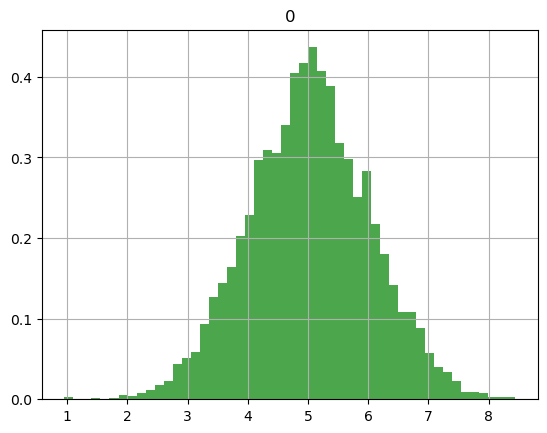

In [16]:
import matplotlib.pyplot as plt

num_bins = 50
sim_df.hist(bins=num_bins,color="green",density=1,alpha = 0.7)

You can see that the histogram shape is generally consistent with a normal random variable. (There are statistical tests of the null of a normal distribution, but I will not go over them here.)

Note that, as we discussed in class, the bulk of the distribution (around 95%) falls between 3 and 7, which is the mean +/- 2 times the standard deviation.


## Increasing the sample size: the law of large numbers in action

One of the survey questions was about the "law of large numbers" which is a hugely important result in probability and statistics. In order to illustrate the LLN, let's dramatically increase our sample size from 100 to 10,000. Then we will re-do the simulation exercise and compare results.

Note that since the standard deviation shrinks at the rate of $\sqrt{N}$, we should now expect the standard deviation to be 0.1, rather than one. 



In [19]:
# up the sample size
N = 10000

# re-do simulation 

#Initialize a holder for our sample means
sim_outcomes_bigN = []
#Now we will do a loop in python:

for i in np.arange(0,B):
    #simulate new data
    sim_x = np.random.normal(loc=xmu, scale=xstd, size=N)
    #compute the mean
    smean = np.mean(sim_x)
    #keep the mean we computed
    sim_outcomes_bigN.append(smean)

#make a Pandas DataFrame (for convenience)
sim_bigN_df = pd.DataFrame(sim_outcomes_bigN)

sim_bigN_df.describe()


,0
count,5000.000000
mean,4.999363
std,0.100155
min,4.617615
25%,4.931126
50%,4.998593
75%,5.066957
max,5.363596


array([[<Axes: title={'center': '0'}>]], dtype=object)

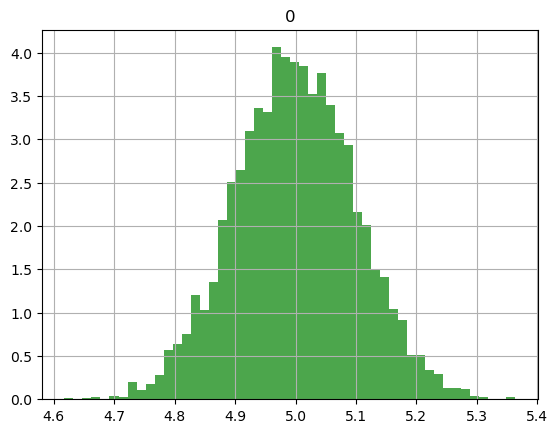

In [21]:
sim_bigN_df.hist(bins=num_bins,color="green",density=1,alpha = 0.7)

## Discussion

See how the sample mean outcomes all "tighten up" around the true mean of 5? This is exactly what the LLN predicts: the sample mean approaches (gets closer and closer to in probability) the true population mean as the sample size becomes arbitrarily large.